In [1]:
import numpy as np
import scipy.io.wavfile as wav
import scipy.signal as signal
import matplotlib.pyplot as plt
import librosa
import os
from glob import glob

In [2]:
music_file = 'music_decomposition/FoxTitle.wav'

In [3]:
sample_rate, music_signal = wav.read(music_file)

/var/folders/yj/v8_dnf_j2cv3dhbnc108tr7w0000gn/T/ipykernel_65086/2373438420.py:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, music_signal = wav.read(music_file)


In [4]:
window_size = 1024
hop_size = 160
window = signal.windows.hann(window_size)


In [5]:

frequencies, times, Zxx = signal.stft(
    music_signal,
    fs=sample_rate,
    window=window,
    nperseg=window_size,
    noverlap=window_size - hop_size,
    nfft=window_size,
    detrend=False,
    return_onesided=True,
    boundary=None,
    padded=False,
    axis=-1
)


In [6]:
M = np.abs(Zxx)
#M = 20 * np.log10(M + 1e-10)

In [7]:
U, S, Vt = np.linalg.svd(M, full_matrices=False)

In [8]:
num_bases = 11
U_bases = U[:, :num_bases]


In [9]:
np.savetxt('musicbases.csv', U_bases, delimiter=',')

In [10]:
notes_dir = 'music_decomposition/'

In [11]:
note_files = glob(os.path.join(notes_dir, '*.wav'))

In [12]:
print(f"Note files: {note_files}")


Note files: ['music_decomposition/G3.wav', 'music_decomposition/G4.wav', 'music_decomposition/A3.wav', 'music_decomposition/EF4.wav', 'music_decomposition/FoxTitle.wav', 'music_decomposition/C4.wav', 'music_decomposition/B3.wav', 'music_decomposition/D4.wav', 'music_decomposition/E3.wav', 'music_decomposition/FS3.wav', 'music_decomposition/D3.wav', 'music_decomposition/E4.wav']


In [13]:
ground_truth_spectra = {}

In [14]:
for note_file in note_files:
 
    note_name = os.path.splitext(os.path.basename(note_file))[0]


    sr, note_signal = wav.read(note_file)

   
    f_note, t_note, Zxx_note = signal.stft(
        note_signal,
        fs=sr,
        window=window,
        nperseg=window_size,
        noverlap=window_size - hop_size,
        nfft=window_size,
        detrend=False,
        return_onesided=True,
        boundary=None,
        padded=False,
        axis=-1
    )

    M_note = np.abs(Zxx_note)

    start_frame = 20  
    end_frame = 40
    steady_frames = M_note[:, start_frame:end_frame]

    avg_spectrum = np.mean(steady_frames, axis=1)

   
    avg_spectrum /= np.linalg.norm(avg_spectrum) + 1e-10

    ground_truth_spectra[note_name] = avg_spectrum


/var/folders/yj/v8_dnf_j2cv3dhbnc108tr7w0000gn/T/ipykernel_65086/1064012445.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, note_signal = wav.read(note_file)


In [15]:
results = []

for i in range(num_bases):
    base = U_bases[:, i]

    # Normalize the base
    base_norm = np.linalg.norm(base)
    print(f"Base {i+1} norm: {base_norm}")
    if base_norm == 0:
        print(f"Base {i+1} has zero norm, skipping.")
        continue
    
    base_normalized = base / (base_norm + 1e-10)

    best_match = None
    highest_inner_product = -1

    for note_name, gt_spectrum in ground_truth_spectra.items():
      
        gt_norm = np.linalg.norm(gt_spectrum)
        print(f"Ground truth note {note_name} norm: {gt_norm}")
        if gt_norm == 0:
            print(f"Ground truth note {note_name} has zero norm, skipping.")
            continue
        
        gt_spectrum_normalized = gt_spectrum / (gt_norm + 1e-10)

        inner_product = np.dot(base_normalized, gt_spectrum_normalized)

        print(f"Base {i+1} vs {note_name}: Inner Product = {inner_product:.4f}")

        if inner_product > highest_inner_product:
            highest_inner_product = inner_product
            best_match = note_name

    if best_match is not None:
        results.append({
            'Base Index': i + 1,
            'Best Match Note': best_match,
            'Inner Product': highest_inner_product
        })
    else:
        results.append({
            'Base Index': i + 1,
            'Best Match Note': None,
            'Inner Product': -1
        })


Base 1 norm: 1.0
Ground truth note G3 norm: 0.9999999403953552
Base 1 vs G3: Inner Product = -0.8563
Ground truth note G4 norm: 1.0
Base 1 vs G4: Inner Product = -0.4697
Ground truth note A3 norm: 0.9999999403953552
Base 1 vs A3: Inner Product = -0.1367
Ground truth note EF4 norm: 1.0000001192092896
Base 1 vs EF4: Inner Product = -0.0860
Ground truth note FoxTitle norm: 0.9999999403953552
Base 1 vs FoxTitle: Inner Product = -0.8610
Ground truth note C4 norm: 0.9999999403953552
Base 1 vs C4: Inner Product = -0.3415
Ground truth note B3 norm: 0.9999998807907104
Base 1 vs B3: Inner Product = -0.2704
Ground truth note D4 norm: 0.9999999403953552
Base 1 vs D4: Inner Product = -0.6861
Ground truth note E3 norm: 1.0
Base 1 vs E3: Inner Product = -0.0985
Ground truth note FS3 norm: 0.9999999403953552
Base 1 vs FS3: Inner Product = -0.2181
Ground truth note D3 norm: 1.0000001192092896
Base 1 vs D3: Inner Product = -0.4985
Ground truth note E4 norm: 1.0000001192092896
Base 1 vs E4: Inner Product

Matching Results:
Base 1:
  Best Match Note: E4
  Inner Product: -0.0437

Base 2:
  Best Match Note: G4
  Inner Product: 0.5282

Base 3:
  Best Match Note: FoxTitle
  Inner Product: 0.3402

Base 4:
  Best Match Note: FS3
  Inner Product: 0.3828

Base 5:
  Best Match Note: D3
  Inner Product: 0.4757

Base 6:
  Best Match Note: G4
  Inner Product: 0.5477

Base 7:
  Best Match Note: EF4
  Inner Product: 0.5578

Base 8:
  Best Match Note: EF4
  Inner Product: 0.6795

Base 9:
  Best Match Note: FS3
  Inner Product: 0.5457

Base 10:
  Best Match Note: A3
  Inner Product: 0.7076

Base 11:
  Best Match Note: B3
  Inner Product: 0.1069

Number of unique notes restored: 8 out of 11


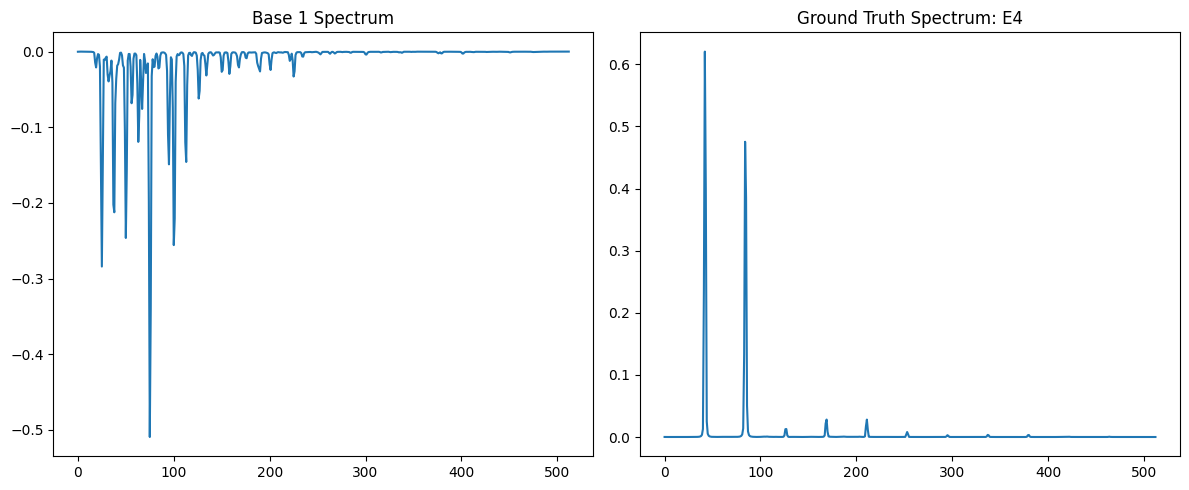

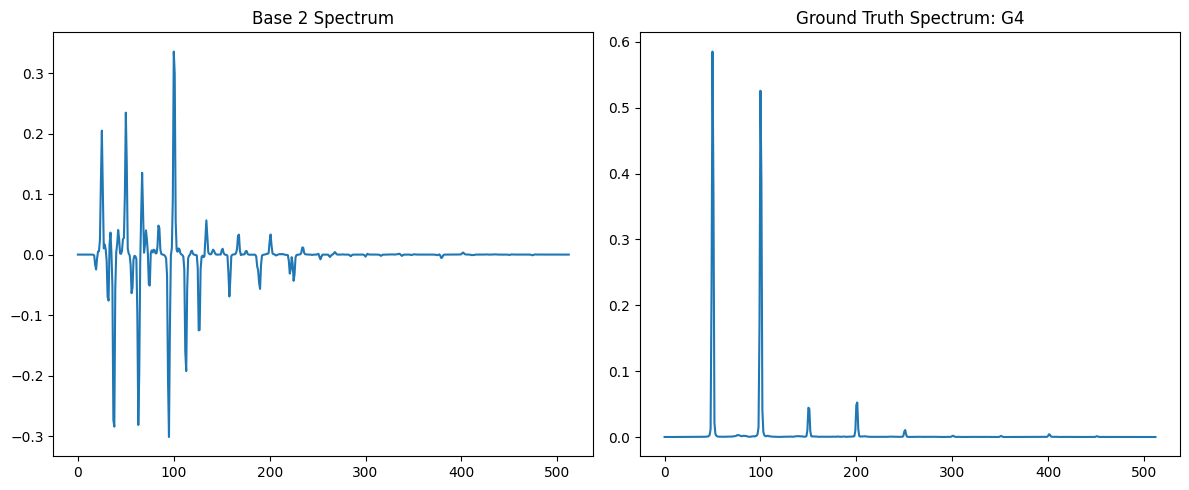

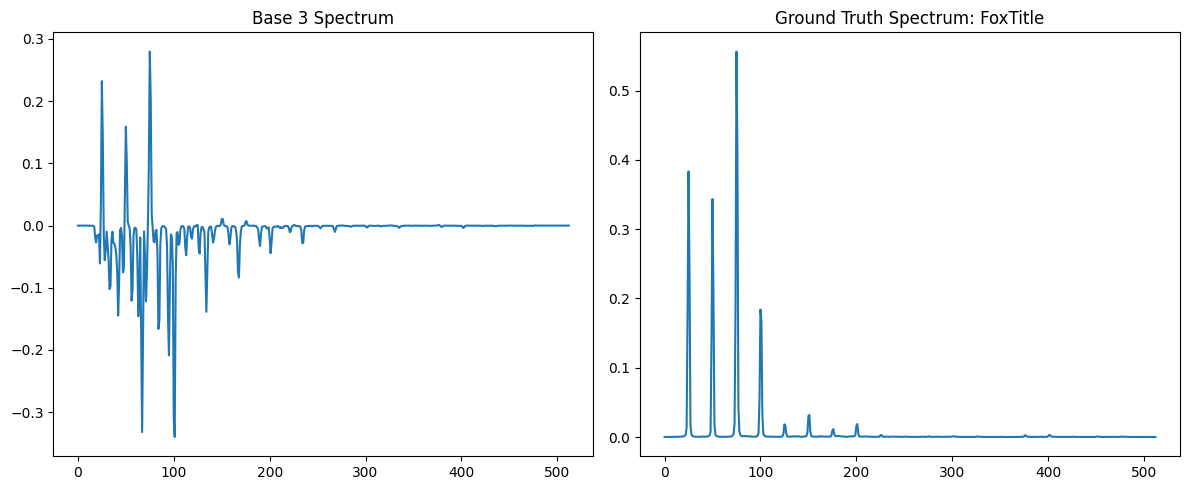

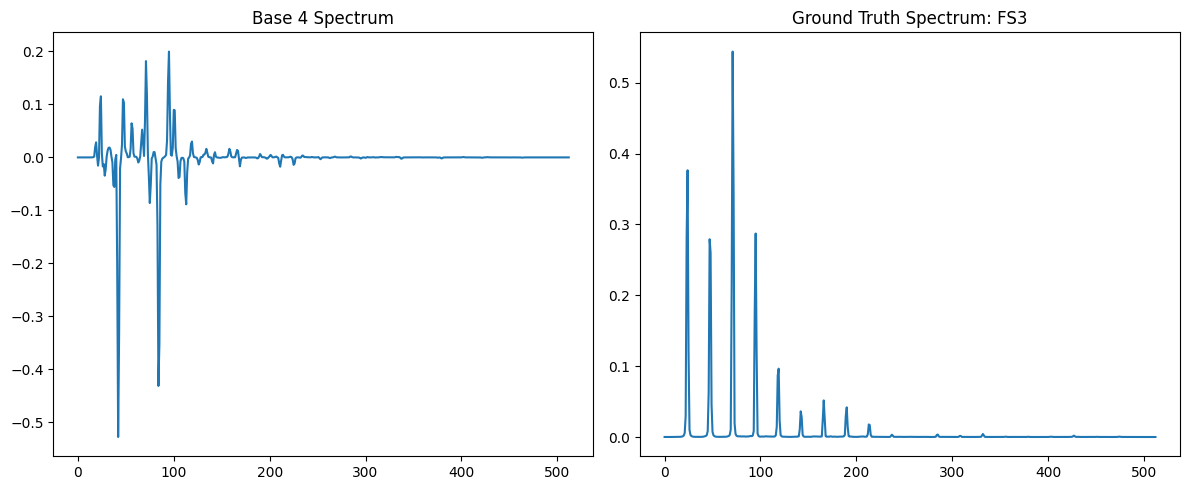

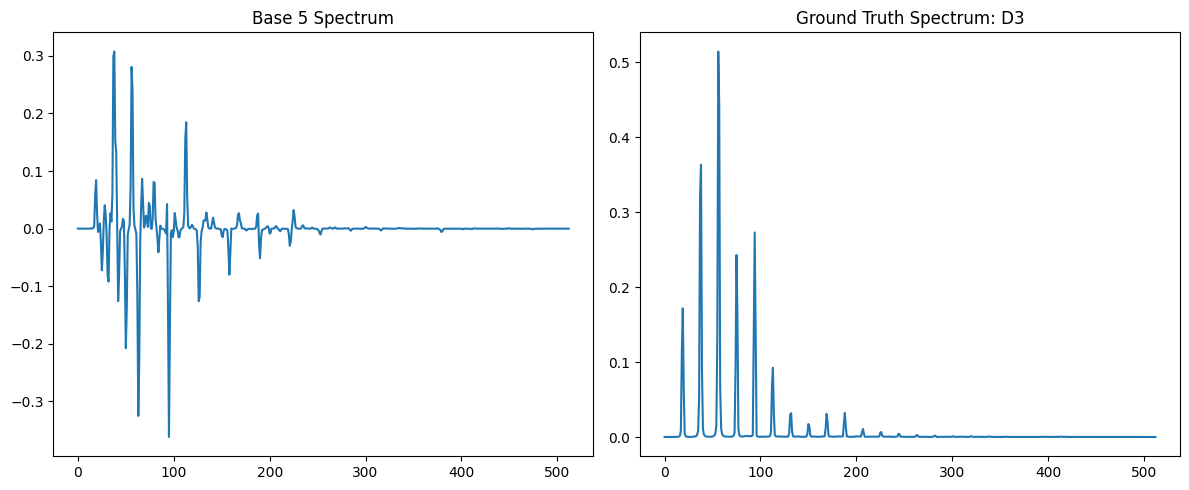

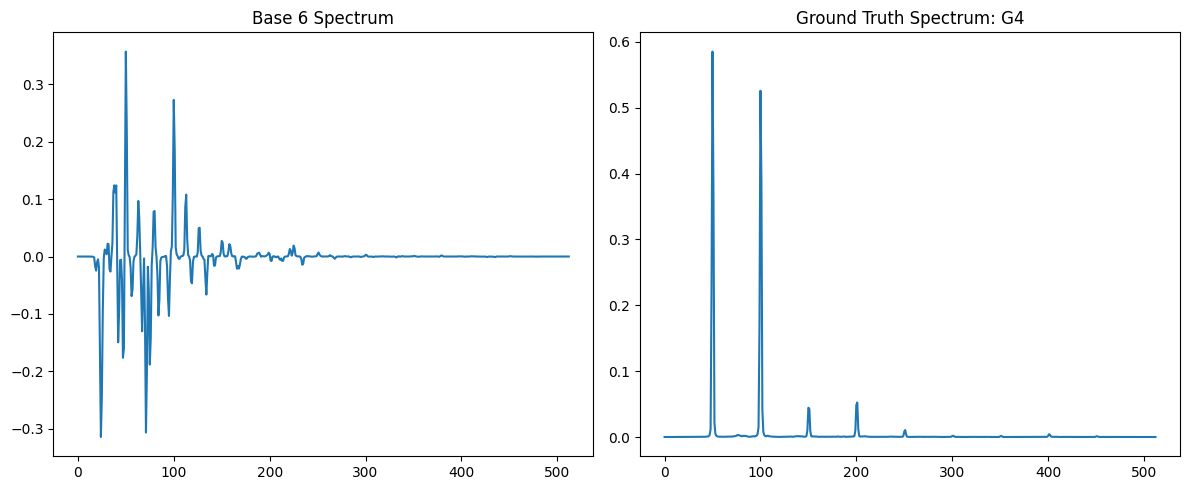

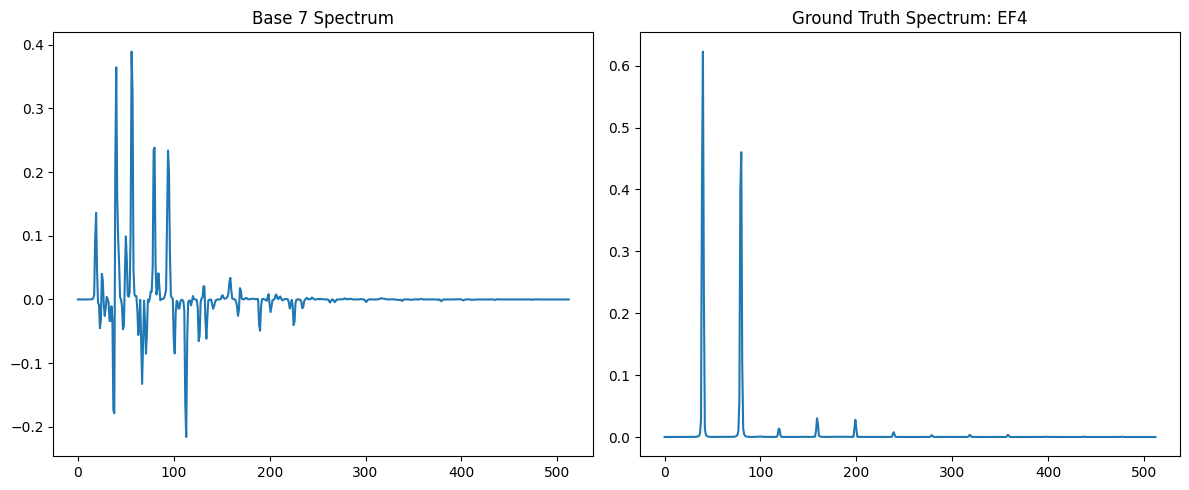

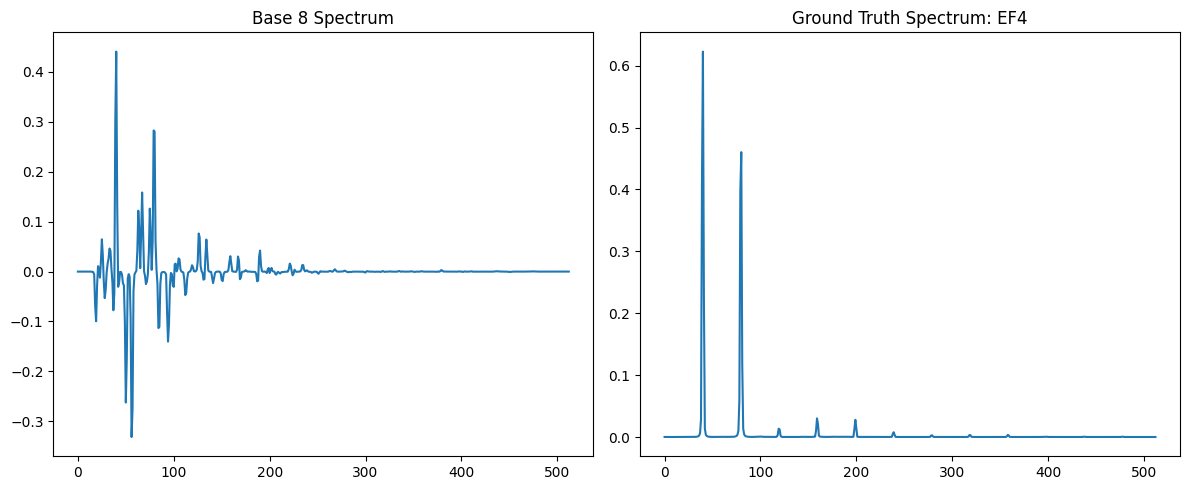

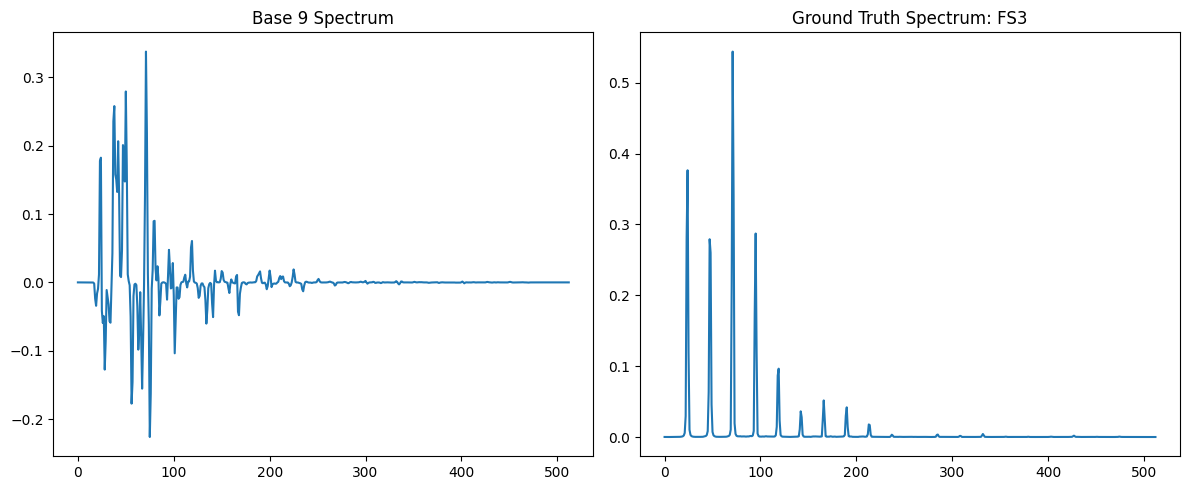

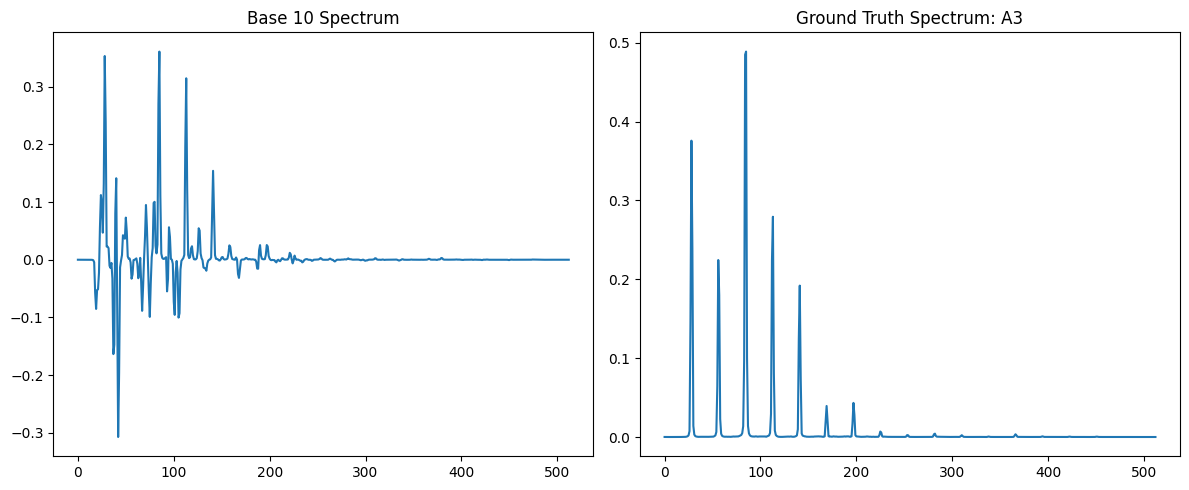

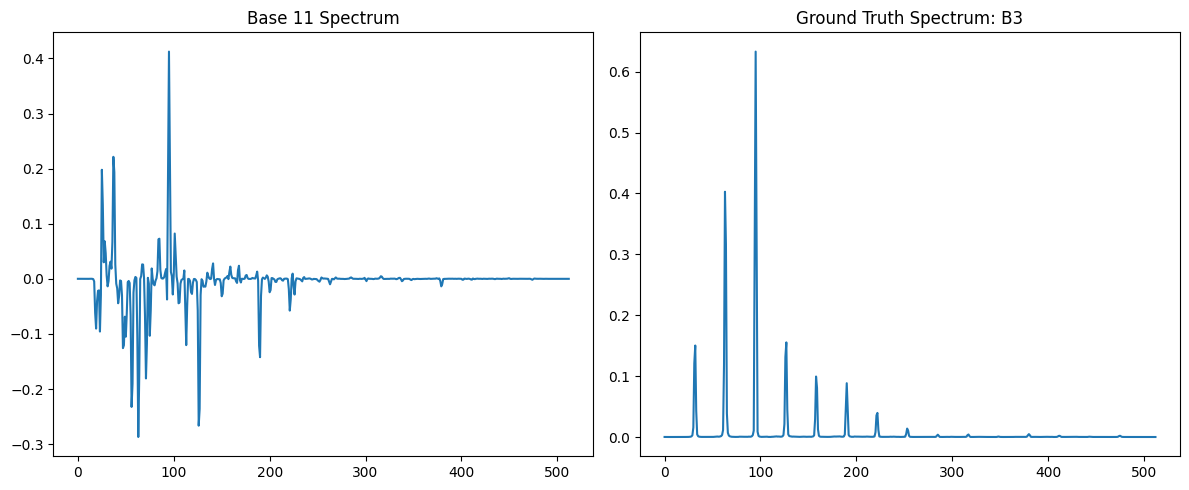

In [16]:
print("Matching Results:")
unique_notes = set()

for result in results:
    print(f"Base {result['Base Index']}:")
    print(f"  Best Match Note: {result['Best Match Note']}")
    print(f"  Inner Product: {result['Inner Product']:.4f}\n")
    unique_notes.add(result['Best Match Note'])

print(f"Number of unique notes restored: {len(unique_notes)} out of 11")

for i, result in enumerate(results):
    base_index = result['Base Index'] - 1
    best_note = result['Best Match Note']

 
    if best_note is not None:
        plt.figure(figsize=(12, 5))

      
        plt.subplot(1, 2, 1)
        plt.plot(U_bases[:, base_index])
        plt.title(f"Base {base_index + 1} Spectrum")

       
        plt.subplot(1, 2, 2)
        plt.plot(ground_truth_spectra[best_note])
        plt.title(f"Ground Truth Spectrum: {best_note}")

        plt.tight_layout()
        plt.show()
    else:
        print(f"No valid match found for Base {i + 1}")


In [17]:
for note_name, gt_spectrum in ground_truth_spectra.items():
    gt_norm = np.linalg.norm(gt_spectrum)
    print(f"Ground truth note {note_name} norm: {gt_norm}")
    if gt_norm == 0:
        print(f"Ground truth note {note_name} has zero norm, skipping.")
        continue
    
    gt_spectrum_normalized = gt_spectrum / (gt_norm + 1e-10)


Ground truth note G3 norm: 0.9999999403953552
Ground truth note G4 norm: 1.0
Ground truth note A3 norm: 0.9999999403953552
Ground truth note EF4 norm: 1.0000001192092896
Ground truth note FoxTitle norm: 0.9999999403953552
Ground truth note C4 norm: 0.9999999403953552
Ground truth note B3 norm: 0.9999998807907104
Ground truth note D4 norm: 0.9999999403953552
Ground truth note E3 norm: 1.0
Ground truth note FS3 norm: 0.9999999403953552
Ground truth note D3 norm: 1.0000001192092896
Ground truth note E4 norm: 1.0000001192092896


### 5.2.2 Why SVD isn’t the best choice:

1. **Low and Inconsistent Inner Product Values**:
   Some of the inner products are quite low or even negative (e.g., -0.0437 for E4 and 0.1069 for B3), which indicates that SVD may not be accurately identifying the notes. This could be because SVD doesn't inherently focus on isolating distinct components that correspond to physical sources like individual musical notes.

2. **Sign Ambiguity**:
   The negative inner product for E4 points to sign ambiguity, where SVD might be reversing the signs of singular vectors. This can cause mismatches when comparing the extracted bases to the ground truth notes, revealing a limitation in SVD for tasks where interpretability and correct sign are important.

3. **Capture of Harmonics/Overtones**:
   The fact that several bases correspond to the same notes (e.g., G4 for both Base 2 and Base 6, EF4 for Base 7 and Base 8) suggests that SVD may be capturing harmonics or overtones instead of isolating the distinct fundamental notes.